# Projekt Końcowy: Analiza Danych Przestrzennych Jakości Życia w USA

Ten notatnik integruje cały proces badawczy: od pobrania i przetworzenia danych (ETL), przez analizę statystyczną, aż po wygenerowanie interaktywnej mapy oraz analizy skupień (Hotspots).


## 1. Import Bibliotek
Importujemy niezbędne biblioteki do analizy danych (`pandas`, `numpy`), analizy przestrzennej (`geopandas`, `folium`, `esda`, `libpysal`) oraz wizualizacji (`matplotlib`).

Uwaga: Dane Census zostały wcześniej pobrane i zapisane lokalnie, aby uniknąć konieczności używania klucza API.


In [1]:
import pandas as pd
import geopandas as gpd
import folium
from folium import plugins
from us import states
import os
import glob
from sklearn.preprocessing import MinMaxScaler
import json
import matplotlib.pyplot as plt
import sys
from libpysal.weights.contiguity import Queen
from esda.moran import Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster

## 2. Konfiguracja ETL
Definiujemy ścieżki do plików źródłowych (Census, Zillow, CDC, szkoły).


In [2]:
CENSUS_DATA_PATH = 'data/census_data.csv'
ZILLOW_HOME_VALUE_PATH = 'data/zillow_home_price.csv'
ZILLOW_RENT_PATH = 'data/zillow_rent.csv'
HOMICIDE_PATH = 'data/cdc_homicide.xls'
SCHOOL_PATH = 'data/schools.csv'


## 3. Funkcje Przetwarzania Danych

Definiujemy funkcje odpowiedziane za wczytanie i wyczyszczenie danych z poszczególnych źródeł:
*   `get_census_data`: Wczytuje przygotowane wcześniej dane demograficzne z pliku CSV.
*   `process_zillow_data`: Przetwarza dane o cenach domów i czynszach.
*   `process_homicide_data`: Przetwarza dane o przyczynach zgonów (CDC), agregując je do poziomu hrabstwa.
*   `process_school_data`: Zlicza liczbę szkół publicznych w każdym hrabstwie.


In [3]:
# 1. CENSUS DATA LOADING (LOCAL)
def get_census_data(filepath):      
    df = pd.read_csv(filepath, dtype={'GEOID': str})
    return df

# 2. ZILLOW DATA PROCESSING
def process_zillow_data(zhvi_path, zori_path):
    df_zhvi = pd.read_csv(zhvi_path)
    df_zhvi['GEOID'] = df_zhvi['StateCodeFIPS'].astype(str).str.zfill(2) + df_zhvi['MunicipalCodeFIPS'].astype(str).str.zfill(3)
    date_cols = [c for c in df_zhvi.columns if c[:2] == '20']
    latest_date = date_cols[-1]
    df_zhvi = df_zhvi[['GEOID', latest_date]].rename(columns={latest_date: 'Median_Home_Price'})

    df_zori = pd.read_csv(zori_path)
    df_zori['GEOID'] = df_zori['StateCodeFIPS'].astype(str).str.zfill(2) + df_zori['MunicipalCodeFIPS'].astype(str).str.zfill(3)
    date_cols = [c for c in df_zori.columns if c[:2] == '20']
    latest_date = date_cols[-1]
    df_zori = df_zori[['GEOID', latest_date]].rename(columns={latest_date: 'Median_Rent'})
        
    return pd.merge(df_zhvi, df_zori, on='GEOID', how='outer')

# 3. HOMICIDE DATA (CDC)
def process_homicide_data(filepath):
    df = pd.read_csv(filepath, sep='\t', dtype={'County Code': str})
    df = df[df['County Code'].notna()]
    df['Deaths'] = pd.to_numeric(df['Deaths'], errors='coerce').fillna(0)
    df['Population'] = pd.to_numeric(df['Population'], errors='coerce').fillna(0)
    
    df_agg = df.groupby('County Code')[['Deaths', 'Population']].sum().reset_index()
    df_agg['Homicide_Rate_per_100k'] = (df_agg['Deaths'] / df_agg['Population']) * 100000
    
    df_agg = df_agg.rename(columns={'County Code': 'GEOID'})
    df_agg['GEOID'] = df_agg['GEOID'].str.zfill(5)
    return df_agg[['GEOID', 'Homicide_Rate_per_100k', 'Deaths', 'Population']]

# 4. SCHOOL DATA
def process_school_data(filepath):    
    df = pd.read_csv(filepath, usecols=['CNTY'])
    df['GEOID'] = df['CNTY'].astype(str).str.zfill(5)
    return df.groupby('GEOID').size().reset_index(name='School_Count')


## 4. Uruchomienie Potoku ETL i Imputacja Danych

Tu następuje wykonanie funkcji, złączenie danych w jeden DataFrame `df_final`. Kluczowym krokiem jest **imputacja danych o zabójstwach**: dla hrabstw bez danych (ukrytych przez CDC z powodu małej liczby zgonów) podstawiamy średnią wartość dla danego stanu.


In [4]:
# 1. Load Data
df_census = get_census_data(CENSUS_DATA_PATH)
df_zillow = process_zillow_data(ZILLOW_HOME_VALUE_PATH, ZILLOW_RENT_PATH)
df_homicide = process_homicide_data(HOMICIDE_PATH).rename(columns={'Population': 'Population_CDC'})
df_schools = process_school_data(SCHOOL_PATH)

# 2. Merge
df_final = pd.merge(df_census, df_zillow, on='GEOID', how='left')
df_final = pd.merge(df_final, df_homicide, on='GEOID', how='left')
df_final = pd.merge(df_final, df_schools, on='GEOID', how='left')

# 3. Imputation (Stat-level average for missing homicide data)
df_final['STATEFP'] = df_final['GEOID'].str[:2]

state_stats = df_final.groupby('STATEFP')[['Deaths', 'Population_CDC']].sum().reset_index()
state_stats['State_Homicide_Rate'] = (state_stats['Deaths'] / state_stats['Population_CDC']) * 100000

df_final = pd.merge(df_final, state_stats[['STATEFP', 'State_Homicide_Rate']], on='STATEFP', how='left')

national_median = df_final['Homicide_Rate_per_100k'].median()
df_final['Homicide_Rate_imputed'] = df_final['Homicide_Rate_per_100k'].fillna(df_final['State_Homicide_Rate'])
df_final['Homicide_Rate_imputed'] = df_final['Homicide_Rate_imputed'].fillna(national_median)

df_final['Homicide_Rate_per_100k'] = df_final['Homicide_Rate_imputed']
df_final = df_final.drop(columns=['Deaths', 'Population_CDC', 'State_Homicide_Rate', 'Homicide_Rate_imputed', 'STATEFP'])

# 4. Computed Metrics
df_final['Home_Price_to_Income_Ratio'] = df_final['Median_Home_Price'] / df_final['Median_Income']

df_final['School_Count'] = df_final['School_Count'].fillna(0)
df_final['School_Density'] = (df_final['School_Count'] / df_final['Population']) * 1000
df_final['School_Density'] = df_final['School_Density'].replace([float('inf'), -float('inf')], 0).fillna(0)

# Przekazanie danych do etapu mapowania (w pamięci)
df_map_input = df_final.copy()


## 5. Konfiguracja Mapy i Przetwarzanie Geometrii
Zmieniono kolejność: Najpierw wczytujemy plik SHP i łączymy z danymi. Następnie czyścimy dane i **DOPIERO WTEDY obliczamy Scoring**. Na końcu filtrujemy geometrię do wizualizacji.


In [5]:
# Map Configuration
SHAPEFILE_PATH = 'data/tl_2025_us_county/tl_2025_us_county.shp'
OUTPUT_MAP_PATH = 'output_maps/final_map_usa.html'
os.makedirs('output_maps', exist_ok=True)

# Load Data (Using in-memory dataframe 'df_map_input')
gdf_raw = gpd.read_file(SHAPEFILE_PATH)

# Merge
gdf = gdf_raw.merge(df_map_input, on='GEOID', how='inner')
if 'NAME_x' in gdf.columns:
    gdf = gdf.rename(columns={'NAME_x': 'NAME'})
if 'NAME_y' in gdf.columns:
    gdf = gdf.drop(columns=['NAME_y'])

gdf_clean = gdf.dropna(subset=['Median_Home_Price', 'Median_Income']).copy()
gdf_clean['Homicide_Rate_per_100k'] = gdf_clean['Homicide_Rate_per_100k'].fillna(gdf_clean['Homicide_Rate_per_100k'].median())
gdf_clean['Education_Bach_Plus_Pct'] = gdf_clean['Education_Bach_Plus_Pct'].fillna(gdf_clean['Education_Bach_Plus_Pct'].median())
gdf_clean['Poverty_Rate_Pct'] = gdf_clean['Poverty_Rate_Pct'].fillna(gdf_clean['Poverty_Rate_Pct'].median())
gdf_clean['Unemployment_Rate_Pct'] = gdf_clean['Unemployment_Rate_Pct'].fillna(gdf_clean['Unemployment_Rate_Pct'].median())


## 6. Algorytm Punktacji (Scoring)
Obliczamy indeks `QoL_Score`. Dodatkowo, zaokrąglamy wszystkie wyniki do 2 miejsc po przecinku dla lepszej czytelności.


In [6]:
# Scoring Algorithm
scaler = MinMaxScaler()
cols_positive = ['Median_Income', 'Education_Bach_Plus_Pct', 'School_Density']
cols_negative = ['Home_Price_to_Income_Ratio', 'Poverty_Rate_Pct', 'Unemployment_Rate_Pct', 'Homicide_Rate_per_100k']

norm_df = pd.DataFrame(scaler.fit_transform(gdf_clean[cols_positive + cols_negative]), 
                       columns=cols_positive + cols_negative, 
                       index=gdf_clean.index)

for col in cols_negative:
    norm_df[col] = 1 - norm_df[col]

# Weights
W_AFFORDABILITY = 0.25
W_SAFETY = 0.20
W_INCOME = 0.15
W_EDUCATION = 0.15
W_POVERTY = 0.15
W_SCHOOLS = 0.10

gdf_clean['QoL_Score'] = (
    norm_df['Home_Price_to_Income_Ratio'] * W_AFFORDABILITY +
    norm_df['Homicide_Rate_per_100k'] * W_SAFETY +
    norm_df['Median_Income'] * W_INCOME +
    norm_df['Education_Bach_Plus_Pct'] * W_EDUCATION +
    norm_df['Poverty_Rate_Pct'] * W_POVERTY +
    norm_df['School_Density'] * W_SCHOOLS
) * 100

# Rounding
cols_to_round = ['QoL_Score', 'Homicide_Rate_per_100k', 'Home_Price_to_Income_Ratio', 
                 'Education_Bach_Plus_Pct', 'Poverty_Rate_Pct', 'Unemployment_Rate_Pct', 
                 'School_Density', 'Median_Income', 'Median_Home_Price', 'Median_Rent']

for col in cols_to_round:
    if col in gdf_clean.columns:
        gdf_clean[col] = gdf_clean[col].round(2)


## 7. Przygotowanie Geometrii Mapy
Filtrujemy hrabstwa (usuwamy Alaskę, Hawaje, Portoryko dla czytelności) i upraszczamy geometrię.


In [7]:
# Geography Filter
gdf_map = gdf_clean[~gdf_clean['STATEFP'].isin(['02', '15', '72'])].copy() # Exclude AK, HI, PR for view
gdf_map['geometry'] = gdf_map.simplify(tolerance=0.05) 


## 8. Funkcje Pomocnicze do Mapy
Funkcje generujące kod HTML dla tabel w panelu bocznym oraz warstwy Choropleth.


In [8]:
# Helper Functions
def get_top10_html(df, col, name, ascending=False):
    top = df.sort_values(by=col, ascending=ascending).head(10)
    top = top[['NAME', col]]
    top.columns = ['Hrabstwo', name]
    return top.to_html(classes='table table-striped table-hover table-condensed table-responsive', index=False, border=0)

style_tooltip = "background-color: black; color: white; font-family: arial; font-size: 12px; padding: 10px; border-radius: 5px;"

def create_choropleth(data, columns, fill_color, legend_name, tooltip_fields, tooltip_aliases, name, show=False, bins=6):
    c = folium.Choropleth(
        geo_data=data, name=name, data=data, columns=columns,
        key_on='feature.properties.GEOID', fill_color=fill_color,
        fill_opacity=0.8, line_opacity=0.3, line_weight=0.5,
        legend_name=legend_name, highlight=True, show=show, bins=bins, overlay=True
    )
    folium.GeoJsonTooltip(fields=tooltip_fields, aliases=tooltip_aliases, style=style_tooltip).add_to(c.geojson)
    return c


## 9. Generowanie Mapy HTML
Tworzymy ostateczną mapę interaktywną.


In [9]:
# HTML Tables
html_qol = get_top10_html(gdf_clean, 'QoL_Score', 'Wynik QoL')
html_safety = get_top10_html(gdf_clean, 'Homicide_Rate_per_100k', 'Zabójstwa/100k', ascending=True)
html_housing = get_top10_html(gdf_clean, 'Home_Price_to_Income_Ratio', 'Cena/Zarobki', ascending=True)
html_income = get_top10_html(gdf_clean, 'Median_Income', 'Mediana Zarobków', ascending=False)
html_education = get_top10_html(gdf_clean, 'Education_Bach_Plus_Pct', 'Wyższe Wykształcenie %', ascending=False)
html_poverty = get_top10_html(gdf_clean, 'Poverty_Rate_Pct', 'Ubóstwo %', ascending=True)
html_unemployment = get_top10_html(gdf_clean, 'Unemployment_Rate_Pct', 'Bezrobocie %', ascending=True)
html_schools = get_top10_html(gdf_clean, 'School_Density', 'Szkoły/1k mieszk.', ascending=False)

# Map Base
m = folium.Map(location=[37.0902, -95.7129], zoom_start=4, tiles=None)
folium.TileLayer('CartoDB dark_matter', name="Dark Mode", control=True).add_to(m)
folium.TileLayer('OpenStreetMap', name="Light Mode", control=True).add_to(m)

# Layers
cp_qol = create_choropleth(gdf_map, ['GEOID', 'QoL_Score'], 'RdYlGn', 'Wynik Jakości Życia (0-100)', 
                          ['NAME', 'QoL_Score'], ['Hrabstwo:', 'QoL:'], "🏆 Jakość Życia", show=True)
cp_safety = create_choropleth(gdf_map, ['GEOID', 'Homicide_Rate_per_100k'], 'OrRd', 'Zabójstwa na 100k',
                             ['NAME', 'Homicide_Rate_per_100k'], ['Hrabstwo:', 'Zabójstwa:'], "🛡️ Bezpieczeństwo", show=False)
cp_housing = create_choropleth(gdf_map, ['GEOID', 'Home_Price_to_Income_Ratio'], 'Spectral_r', 'Stosunek Ceny Domu do Zarobków',
                              ['NAME', 'Home_Price_to_Income_Ratio'], ['Hrabstwo:', 'Ratio:'], "🏠 Przystępność Cenowa", show=False)
cp_income = create_choropleth(gdf_map, ['GEOID', 'Median_Income'], 'Greens', 'Mediana Zarobków ($)',
                              ['NAME', 'Median_Income'], ['Hrabstwo:', 'Zarobki:'], "💰 Zarobki", show=False)
cp_education = create_choropleth(gdf_map, ['GEOID', 'Education_Bach_Plus_Pct'], 'Blues', 'Wyższe Wykształcenie (%)',
                                 ['NAME', 'Education_Bach_Plus_Pct'], ['Hrabstwo:', 'Wykształcenie:'], "🎓 Edukacja", show=False)
cp_poverty = create_choropleth(gdf_map, ['GEOID', 'Poverty_Rate_Pct'], 'Reds', 'Wskaźnik Ubóstwa (%)',
                               ['NAME', 'Poverty_Rate_Pct'], ['Hrabstwo:', 'Ubóstwo:'], "📉 Ubóstwo", show=False)
cp_unemployment = create_choropleth(gdf_map, ['GEOID', 'Unemployment_Rate_Pct'], 'Purples', 'Stopa Bezrobocia (%)',
                                    ['NAME', 'Unemployment_Rate_Pct'], ['Hrabstwo:', 'Bezrobocie:'], "💼 Bezrobocie", show=False)
cp_schools = create_choropleth(gdf_map, ['GEOID', 'School_Density'], 'YlOrBr', 'Szkoły na 1000 mieszk.',
                               ['NAME', 'School_Density'], ['Hrabstwo:', 'Szkoły/1k:'], "🏫 Dostępność Szkół", show=False)

m.add_child(cp_qol)
m.add_child(cp_safety)
m.add_child(cp_housing)
m.add_child(cp_income)
m.add_child(cp_education)
m.add_child(cp_poverty)
m.add_child(cp_unemployment)
m.add_child(cp_schools)

# Layer Control
folium.plugins.GroupedLayerControl(
    groups={
        'Wybierz Wskaźnik': [cp_qol, cp_income, cp_housing, cp_poverty, cp_unemployment, cp_education, cp_safety, cp_schools]
    },
    exclusive_groups=True,
    collapsed=False
).add_to(m)

# Dynamic Panel HTML
floating_panel_html = f'''
<div id="info-panel" style="
    position: fixed; bottom: 50px; left: 50px; width: 300px; height: auto; max-height: 400px;
    background-color: rgba(255, 255, 255, 0.9); border: 2px solid grey; border-radius: 10px;
    z-index: 9999; font-family: Arial, sans-serif; font-size: 12px; overflow-y: auto;
    box-shadow: 3px 3px 10px rgba(0,0,0,0.5); padding: 10px; display: block;
">
    <h4 style="margin-top:0; text-align:center; border-bottom:1px solid #ccc; padding-bottom:5px;">
        📊 Top 10: <span id="layer-title">Quality of Life</span>
    </h4>
    <div id="table-qol" style="display:block;">{html_qol}</div>
    <div id="table-safety" style="display:none;">{html_safety}</div>
    <div id="table-housing" style="display:none;">{html_housing}</div>
    <div id="table-income" style="display:none;">{html_income}</div>
    <div id="table-education" style="display:none;">{html_education}</div>
    <div id="table-poverty" style="display:none;">{html_poverty}</div>
    <div id="table-unemployment" style="display:none;">{html_unemployment}</div>
    <div id="table-schools" style="display:none;">{html_schools}</div>
    <div style="text-align:center; margin-top:10px; font-size:10px; color:#666;">
        Kliknij warstwę w legendzie, aby zmienić tabelę.
    </div>
</div>

<script>
    var layerMap = {{
        "🏆 Jakość Życia": "table-qol",
        "🛡️ Bezpieczeństwo": "table-safety",
        "🏠 Przystępność Cenowa": "table-housing",
        "💰 Zarobki": "table-income",
        "🎓 Edukacja": "table-education",
        "📉 Ubóstwo": "table-poverty",
        "💼 Bezrobocie": "table-unemployment",
        "🏫 Dostępność Szkół": "table-schools"
    }};

    function updateTable(layerName) {{
        console.log("Layer selected:", layerName);
        var titleSpan = document.getElementById('layer-title');
        if (titleSpan) titleSpan.innerText = layerName.replace(/🏆|🛡️|🏠|💰|🎓|📉|💼|🏫/g, '').trim();
        for (var key in layerMap) {{
            var divId = layerMap[key];
            var el = document.getElementById(divId);
            if (el) el.style.display = 'none';
        }}
        if (layerName in layerMap) {{
            var activeId = layerMap[layerName];
            var activeEl = document.getElementById(activeId);
            if (activeEl) activeEl.style.display = 'block';
        }}
    }}
    
    window.onload = function() {{
        for(var name in window) {{
            if (name.startsWith('map_') && window[name] instanceof L.Map) {{
                var map = window[name];
                map.on('overlayadd', function(e) {{ updateTable(e.name); }});
                updateTable("🏆 Jakość Życia");
                break;
            }}
        }}
    }};
</script>
'''

m.get_root().html.add_child(folium.Element(floating_panel_html))

# Extras
plugins.Search(layer=cp_qol.geojson, geom_type='Polygon', placeholder='Szukaj hrabstwa...', collapsed=True, search_label='NAME', weight=3).add_to(m)
plugins.MiniMap(toggle_display=True).add_to(m)

# Save
m.save(OUTPUT_MAP_PATH)
print(f"Mapa zapisana: {OUTPUT_MAP_PATH}")


Mapa zapisana: output_maps/final_map_usa.html


## 10. Analiza Hotspot (LISA)
Wyznaczamy statystycznie istotne klastry (skupiska) wysokich i niskich wartości wskaźnika Quality of Life. Używamy wskaźnika **Local Moran's I**.

*   🔴 **High-High (Czerwony)**: Hrabstwa o wysokim QoL otoczone przez inne o wysokim QoL (Oazy Dobrobytu).
*   🔵 **Low-Low (Niebieski)**: Hrabstwa o niskim QoL otoczone przez inne o niskim QoL (Bieguny Problemów).
*   ⚪ **Szary**: Brak statystycznie istotnej zależności.


('WARNING: ', 144, ' is an island (no neighbors)')
('WARNING: ', 169, ' is an island (no neighbors)')
('WARNING: ', 220, ' is an island (no neighbors)')
('WARNING: ', 255, ' is an island (no neighbors)')
('WARNING: ', 274, ' is an island (no neighbors)')
('WARNING: ', 276, ' is an island (no neighbors)')
('WARNING: ', 278, ' is an island (no neighbors)')
('WARNING: ', 289, ' is an island (no neighbors)')
('WARNING: ', 308, ' is an island (no neighbors)')
('WARNING: ', 366, ' is an island (no neighbors)')
('WARNING: ', 373, ' is an island (no neighbors)')
('WARNING: ', 404, ' is an island (no neighbors)')
('WARNING: ', 429, ' is an island (no neighbors)')
('WARNING: ', 460, ' is an island (no neighbors)')
('WARNING: ', 466, ' is an island (no neighbors)')
('WARNING: ', 489, ' is an island (no neighbors)')
('WARNING: ', 551, ' is an island (no neighbors)')
('WARNING: ', 555, ' is an island (no neighbors)')
('WARNING: ', 600, ' is an island (no neighbors)')
('WARNING: ', 616, ' is an isla

C:\Users\rtome\AppData\Local\Temp\ipykernel_9220\2644388291.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_lisa)
C:\Users\rtome\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 275 disconnected components.
 There are 162 islands with ids: 144, 169, 220, 255, 274, 276, 278, 289, 308, 366, 373, 404, 429, 460, 466, 489, 551, 555, 600, 616, 667, 746, 749, 825, 834, 837, 859, 861, 866, 882, 896, 903, 916, 917, 952, 958, 981, 982, 1000, 1024, 1025, 1026, 1046, 1078, 1081, 1089, 1099, 1146, 1182, 1203, 1213, 1224, 1233, 1239, 1269, 1276, 1279, 1289, 1291, 1292, 1295, 1297, 1304, 1306, 1317, 1325, 1326, 1334, 1397, 1417, 1449, 1450, 1461, 1483, 1495, 1500, 1546, 1587, 1608, 1

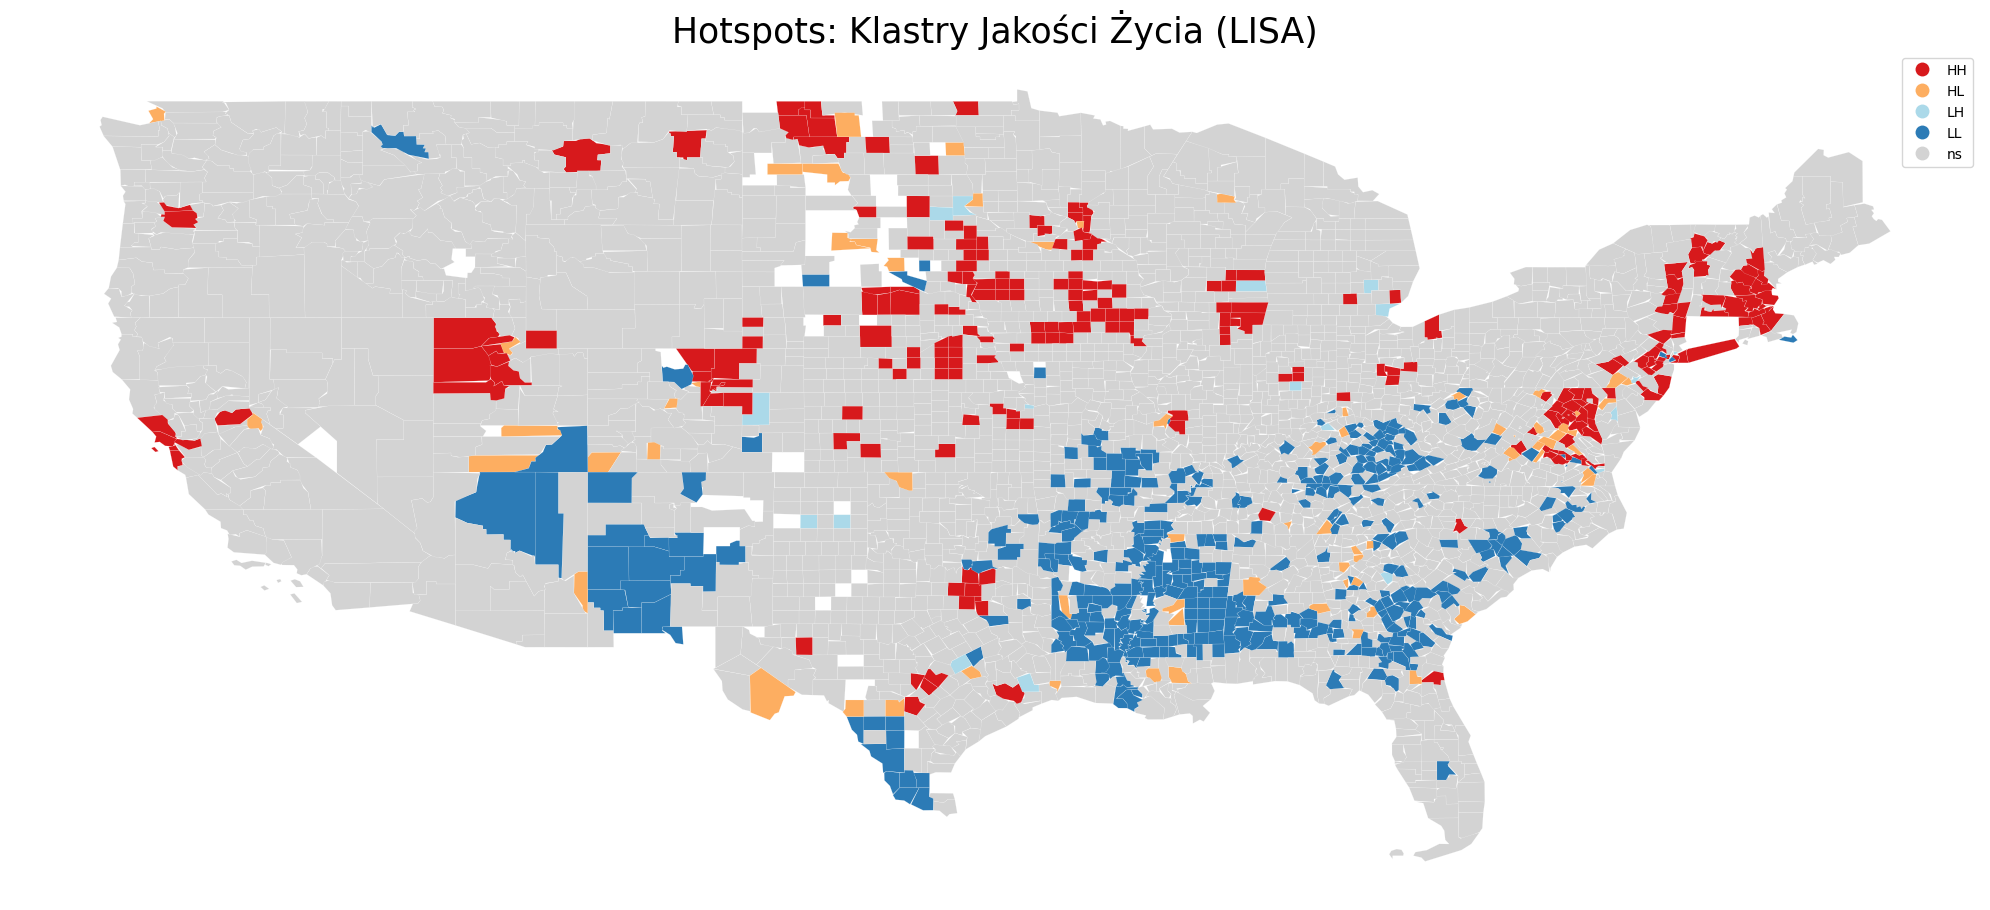

Mapa zapisana: output_maps/static_map_hotspots.png


In [10]:
# Hotspot Analysis
# 0. Clean NA/Inf for spatial stats if any left
gdf_lisa = gdf_map.dropna(subset=['QoL_Score']).copy()

# 1. Weights
w = Queen.from_dataframe(gdf_lisa)
w.transform = 'r'

# 2. Moran
y = gdf_lisa['QoL_Score'].values
moran_loc = Moran_Local(y, w)

# 3. Plot
fig, ax = plt.subplots(figsize=(20, 15))
lisa_cluster(moran_loc, gdf_lisa, p=0.05, ax=ax)
plt.title('Hotspots: Klastry Jakości Życia (LISA)', fontsize=25)
plt.tight_layout()
plt.savefig('output_maps/static_map_hotspots.png', dpi=300)
plt.show()
print("Mapa zapisana: output_maps/static_map_hotspots.png")

